In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
X1 = np.random.randn(100,1)
X2 = np.random.randn(100,1) * 1000
X = np.hstack([X1, X2])
y = 3*X1 + 0.5*X2 + np.random.randn(100,1)

In [2]:
# Add bias column
X_bias = np.hstack([np.ones((X.shape[0],1)), X])

# Initialize parameters
theta = np.zeros((3,1))

learning_rate = 0.0000001
iterations = 200

loss_history = []
theta_history = []

for i in range(iterations):

    y_pred = X_bias @ theta

    error = y_pred - y

    loss = np.mean(error**2)

    gradient = (2/len(X)) * X_bias.T @ error

    theta = theta - learning_rate * gradient

    loss_history.append(loss)
    theta_history.append(theta.copy())

print("Final parameters (no scaling):")
print(theta)

Final parameters (no scaling):
[[2.89244850e-06]
 [3.82144860e-05]
 [4.99562747e-01]]


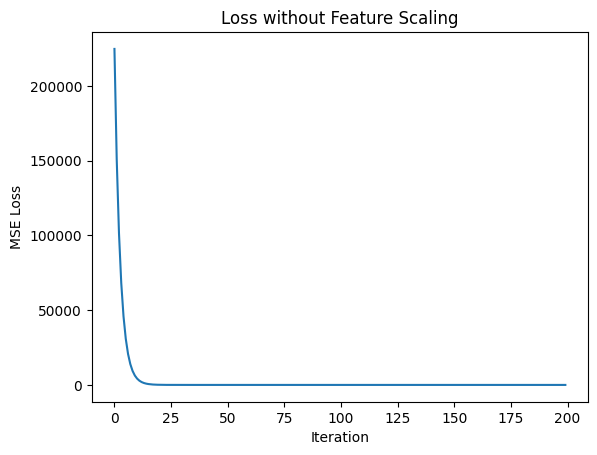

In [3]:
plt.plot(loss_history)
plt.title("Loss without Feature Scaling")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
# Add bias again
X_scaled_bias = np.hstack([np.ones((X_scaled.shape[0],1)), X_scaled])

theta_scaled = np.zeros((3,1))

learning_rate = 0.01
iterations = 200

loss_scaled_history = []
theta_scaled_history = []

for i in range(iterations):

    y_pred = X_scaled_bias @ theta_scaled

    error = y_pred - y

    loss = np.mean(error**2)

    gradient = (2/len(X_scaled)) * X_scaled_bias.T @ error

    theta_scaled = theta_scaled - learning_rate * gradient

    loss_scaled_history.append(loss)
    theta_scaled_history.append(theta_scaled.copy())

print("Final parameters (with scaling):")
print(theta_scaled)

Final parameters (with scaling):
[[ 10.71384223]
 [ -2.03062722]
 [464.73847274]]


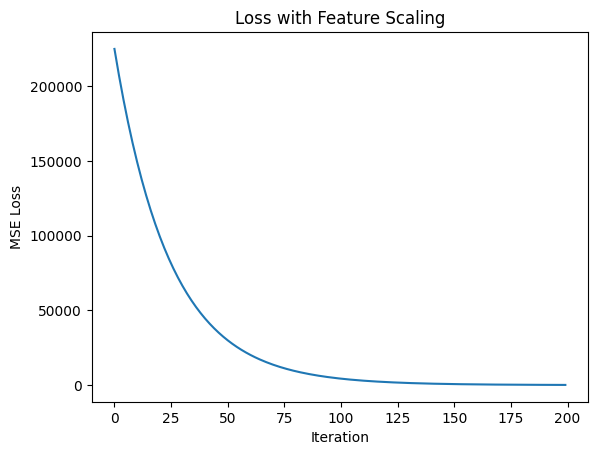

In [6]:
plt.plot(loss_scaled_history)
plt.title("Loss with Feature Scaling")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.show()

Q1


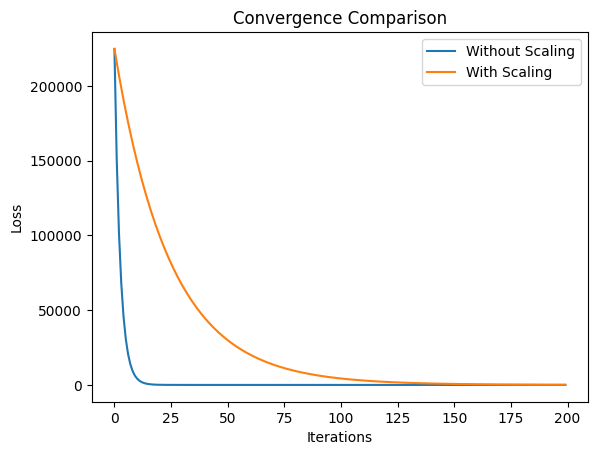

In [17]:
plt.plot(loss_history, label="Without Scaling")
plt.plot(loss_scaled_history, label="With Scaling")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Convergence Comparison")
plt.legend()
print("Q1")
plt.show()

Q2


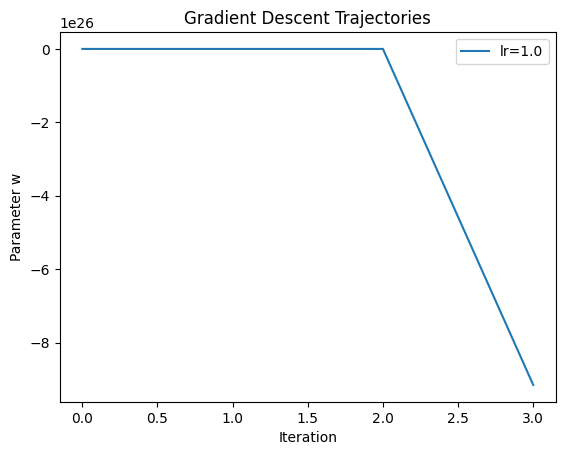

In [15]:
# Q2
import torch
import matplotlib.pyplot as plt

def loss_function(w):
    return w**4 - 3*w**3 + 2

def gradient(w):
    return 4*w**3 - 9*w**2

def gradient_descent(lr):
    w = torch.tensor([2.0])
    trajectory = []

    for i in range(50):
        w = w - lr * gradient(w)
        trajectory.append(w.item())

    return trajectory

# learning_rates = [0.001, 0.01, 0.1, 1.0]

trajectories = {}
lr = 1.0
# for lr in learning_rates:
trajectories[lr] = gradient_descent(lr)
plt.plot(trajectories[lr], label=f"lr={lr}")
# for lr in learning_rates:
#     plt.plot(trajectories[lr], label=f"lr={lr}")
print("Q2")
plt.xlabel("Iteration")
plt.ylabel("Parameter w")
plt.title("Gradient Descent Trajectories")
plt.legend()
plt.show()

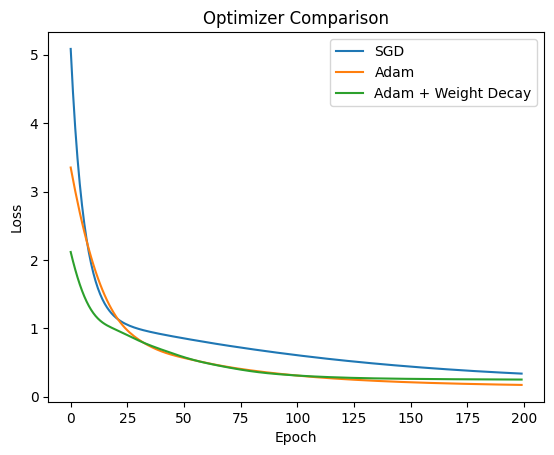

In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

X = torch.linspace(-2,2,100).view(-1,1)
y = X**2 + 0.3*torch.randn_like(X)

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(1,10)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(10,1)

    def forward(self,x):
        x = self.relu(self.linear1(x))
        return self.linear2(x)

def train_model(optimizer_type, weight_decay=0):

    model = SimpleNet()

    if optimizer_type == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_type == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=weight_decay)

    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(200):

        optimizer.zero_grad()

        output = model(X)

        loss = loss_fn(output, y)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    return losses


sgd_loss = train_model("SGD")
adam_loss = train_model("Adam")
adam_decay_loss = train_model("Adam", weight_decay=0.1)

plt.plot(sgd_loss, label="SGD")
plt.plot(adam_loss, label="Adam")
plt.plot(adam_decay_loss, label="Adam + Weight Decay")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()